## Sentiment Analysis of Student Reviews
### Identifying Actionable Feedback from RateMyProfessors Text Reviews
By: Bikalpa Panthi


## 1. Research Question and Motivation
### What information do open-text student reviews provide beyond numerical ratings, and can text analysis identify actionable feedback that ratings alone miss?
Course evaluations are a central component of the quality assurance infrastructure for higher education institutions. Institutions mainly use numerical averages of course evaluations to evaluate effective teaching. The problem with using numerical evaluations is that they condense extensive and complex information into one simple number. For example, if an instructor receives a rating of 3.5 from students, they may be rated/nearly equally for being knowledgeable but disorganized, and the data cannot show these differences because of the collapsing nature of the data.

On the other hand, comments made by students provide a wealth of information that describes the things that students appreciate or dislike in their professors' teaching and the particular behaviors or actions of instructors that lead to satisfaction or dissatisfaction.

This project will investigate the use of machine learning techniques on a very large set of reviews collected from RateMyProfessors.com to evaluate the effectiveness of course evaluations as a measure of positive and negative sentiments of student reviews and to identify the words and phrases that influence students' positive and negative ratings. The aim of this project is to identify clear recurring themes, such as whether interpersonal warmth is more important than the difficulty of the course, which might help inform the development of future faculty development programs such as the Learning Innovation Fellowship (LIF) at Duke Kunshan University (DKU).

## 2. Data
### 2.1 Data Source and basics of the data
For this project, I used a publically available dataset collected from student reviewers who submitted comments to RateMyProfessors. This dataset contains Names of the professor, student reviews: 480,342 total; review text and numerical ratings (1–5). 
### 2.2 Unit of Analysis and Key Variables
Each student review is considered a unit of analysis, with the key variables being the review text and whether the review is sentimentally positive (1) or negative (0) based on the corresponding numerical rating code—the following way: ratings (4 and 5) are coded positively (1); raters (1 and 2) are coded negatively (0); ratings = 3 are removed as ambiguous cases.
### 2.3 Data Cleaning Pipeline
Pipeline: removal of half-point ratings (1.5, 2.5, 3.5, 4.5), lowercasing all text, URL removal, whitespace normalization, removal of short reviews (fewer than 5 words), creation of binary sentiment labels, removal of neutral ratings (rating = 3), and finally a 70/30 train-test split. After cleaning, 436,836 reviews remain, split into 305,785 (70%) training reviews and 131,051 (30%) test reviews.
### 2.4 Class Distribution
The resulting dataset exhibits a class imbalance with a positive to negative ratio of approximately 2.6:1.
Positive: 316, 271 reviews (72,4%)
Negative: 120, 565 reviews (27.6%)
### 2.5 Ethical Considerations
RateMyProfessors reviews are voluntarily submitted by students and therefore contain only structurally identifiable information such as the professor's name. However, there may also be an element of self-selection bias in this data due to the students' extreme sentiments. Therefore, it would be prudent to approach this phase of the study cautiously, particularly when determining aggregate linguistic differences instead of highly singular student identifiers.

## 3. Problem Setup
**ML Task:** Binary text classification (sentiment analysis).

**Target Variable:** Binary sentiment (1 = positive, 0 = negative), derived from numerical ratings

**Input Features:** TF-IDF representations of review text, using unigrams and bigrams with a vocabulary of 10,000 features.

**Assumptions:** The binary coding assumes that rating 3 is ambiguous and that the text content of a review is the primary signal for sentiment. The 'bag of words' assumption underlying TF-IDF means word order is not captured, which limits the model’s ability to handle negation and sarcasm.

## 4. Methods
### 4.1 Feature Engineering: TF-IDF Configuration
Text features are extracted using TF-IDF, which weights words by their frequency within a document relative to their frequency across the entire corpus. I ended up finalizing the following configurations based on their effects as mentioned below:
Domain Stopwords: Removing them hurt LR accuracy by 0.7% --> Keep English + domain stopwords
Vocabulary Size: 10K improved LR accuracy by 0.45% over 5K --> Use 10,000 features
N-gram Range: Unigrams+bigrams improved LR by 0.75% --> Use (1, 2) n-gram range
Stemming: Stemming reduced LR accuracy by 0.25%	--> No stemming

### 4.2 Baseline Model: Naive Bayes
Naive Bayes is the baseline model as it is fast to train and predict which makes it good to benchmark other models against. The assumption of the Naive Bayes model is that the features are conditionally independent of each other given the class label (class in this case is sentiment of the phrase); however, this is a strong assumption that does not hold true for phrases such as, "not good" because the meaning of that phrase depends on the ordering of the words used in the phrase. To account for new words that may not have been seen previously within the training data, Laplace smoothing is applied (alpha = 1.0). Even with its simple nature, Naive Bayes can serve as reasonable competitive baseline for text classification and can also provide probability estimates of the frequency of words contributing to a given sentiment.

### 4.3 Selected Model: Logistic Regression
I chose Logistic Regression as the primary model for various reasons, one reason being the interpretation of coefficients allows to determine how the presence or absence of individual words affects likelihood of being in the positive sentiment class. Secondly, the use of class_weight='balanced' will allow Logistic Regression to account for the large class imbalance (2.6:1 ratio) in the data by applying an inverse weighting scheme across all classes, thus penalizing the misclassification of cases from the minority class more so than cases from the majority class. Thirdly, Logistic Regression provides well-calibrated (accurate) probabilities, allowing for the use of the confidence associated with each probability in downstream decision making. Logistic Regression will use L2 (C = 1.0) regularization techniques along with the utilization of the liblinear solver, which is an effective technique to maximize computational time efficiency when dealing with high-dimensional sparse data sets.

## 5. Evaluation
### 5.1 Train/Test Split Strategy
A 30/70 stratified train/test split was conducted between the training reviews and the testing reviews of the training set. There are 305,785 training and 131,051 test reviews. The proper class distribution was preserved for both sets. A held out test set is being used (rather than relying solely on cross-validation) due to the data set being large enough to use for both training purposes as well as for reliable evaluation. The fixed nature of the test set allows for consistent comparison between the various models and experiments you will be conducting.
### 5.2 Metrics
I have used 4 metrics to report performance - Accuracy (Overall Correct), Precision (Proportion of Predicted Positive Reviews that are True Positive Reviews), Recall (Proportion of Actual Positive Reviews that were Identified Accurately) and F1 (The Harmonic Mean of Precision and Recall). The F1 metric is particularly key because of the unbalanced data and it will provide more useful information about the model's performance than accuracy alone.
### 5.3 Main Results
Both Logistic Regression and Naive Bayes perform well with over 92% accuracy. However, because Logistic Regression has a greater degree of precision than that of Naive Bayes (as well as greater accuracy than that of Naive Bayes), it is better able to discriminate between the class when it identifies a positive review (92.9% accuracy for identifying all positive reviews, and 97.5% accuracy for identifying true positives and 93% for true negatives). Logistic Regression is less conservative and more precise, with 78.8% true negatives and 97.5% true positives, while Naive Bayes is more subjective, achieving greater recall (97.5% versus 92.9%) but also more false positives than Logistic Regression. In terms of performance between the two models, Logistic Regression corrects for 93% of true negatives and 92.9% of true positives, whereas Naive Bayes corrects for 78.8% of true negatives and 97.5% of true positives.
### 5.4 Feature Importance
The top predictive features from Logistic Regression reveal what drives student sentiment:
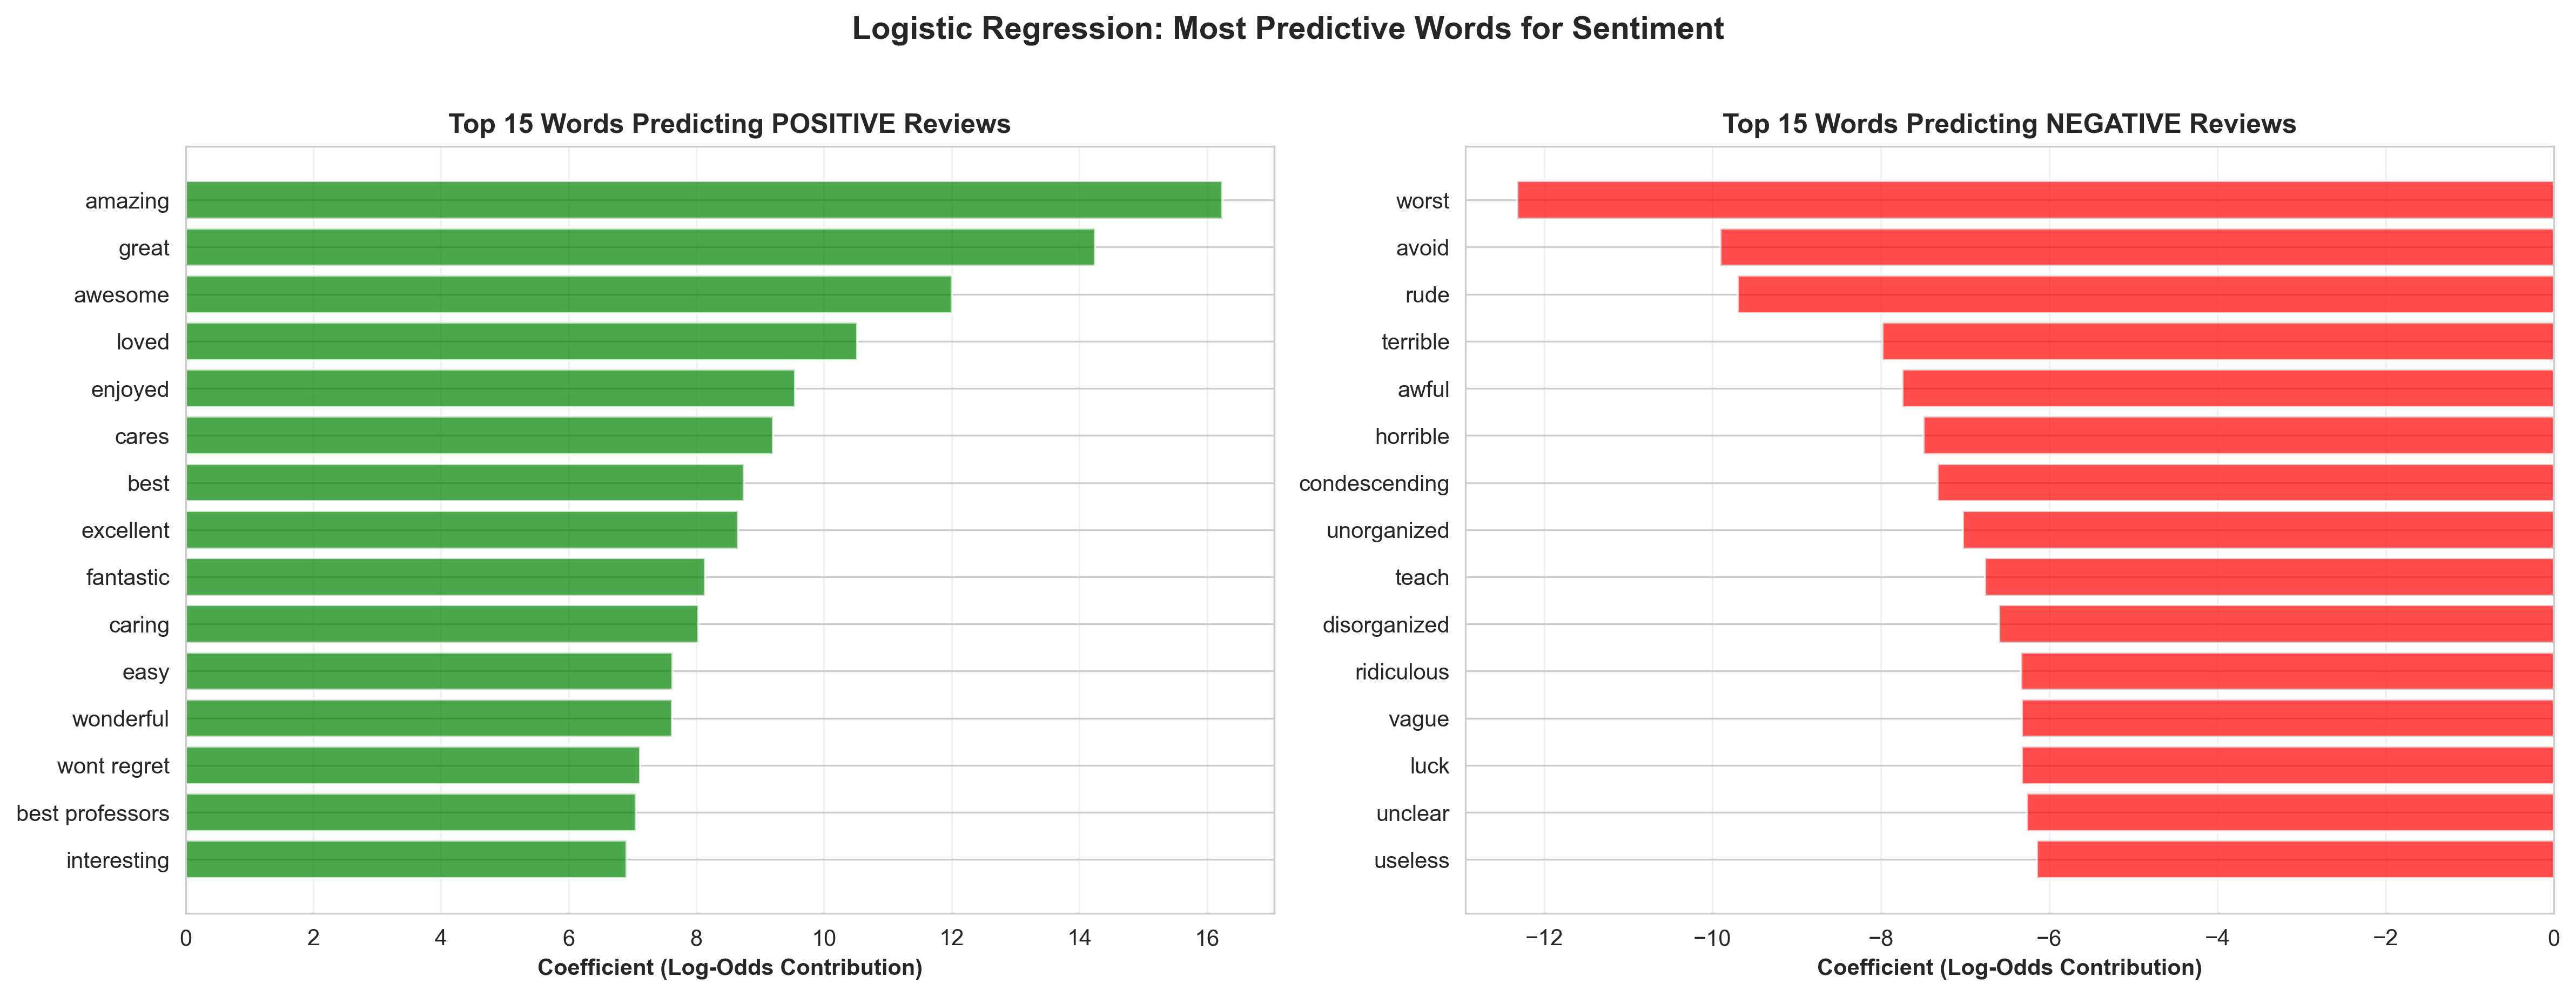

## 6. Error Analysis and Diagnostics
### 6.1 Confidence Analysis
When comparing the model’s confidence level when making decisions about different reviews, an evident difference exists between those that classify correctly and those that do so incorrectly. Reviews that correctly classify have a mean confidence of 92.6% whereas reviews that incorrectly classify have an average confidence of only 71%. This information provides evidence that the model’s predictions are useful as the results suggest that predictions made with low levels of confidence may require a second human verification to confirm that they were made correctly and could provide a useful means for maintaining quality control in production environments.
### 6.2 Where Models Struggle
The main area of weakness for both models occurs around words that have been negated. For example, the phrase “not amazing” would have been treated by both models as a positive word due to being comprised only of positive words, regardless of the fact that it is conveying a negated thought or idea. The distribution of negative errors shows that the largest category of errors is that of negation, the second largest is due to sarcasm, and the third largest is the result of mixed sentiment expressions. A supplemental study involving the use of negation tokens (e.g., converting “not good” into “NEG_good”) produced small improvements but did not resolve our negation issue altogether.
### 6.3 Model Calibration
Calibration curve analysis reveals that Logistic Regression is well-calibrated: its predicted probabilities closely track the diagonal, meaning that when the model predicts 80% positive probability, approximately 80% of those reviews are indeed positive. Naive Bayes, by contrast, tends to produce more extreme probability estimates and is less well-calibrated. This makes Logistic Regression’s probability outputs more trustworthy for downstream applications.
### 6.4 Robustness Checks
![Robustness Checks](<attachment:Weixin Image_2026-02-27_211106_542.png>)
The reliability of our results across different data partitions has been established by conducting a five-fold cross-validation procedure, as all metrics produced extremely low standard deviations (< 0.001). Furthermore, we created an experimental temporal ethics scenario using the sequential row-order validation technique to validate our predictive models by using data from early training periods and validating them against data from later training periods. For example, the accuracy of the results for the Early/Recent split and the Early + Middle/Recent split for the Logistic Regression method were 92.51% and 92.65%, respectively, providing no significant evidence of negative performance differences.
Additionally, we performed a sample size sensitivity analysis to determine how Logistic Regression would perform using only 10% of the total training set (approx. 26,000 reviews) and found that it still produced 91.3% accuracy. The results also indicate that there are diminishing returns on using greater amounts of the training set and that the models are efficient.
### 6.5 Feature Stability
19 of the top 20 features remain highly stable across different resample types within K-Fold and bootstrap analysis. The words “amazing,” “great,” and “worst” also exhibit a stability score of 1.0 and have a 100% sign consistency. As such, the model’s interpretations regarding which words contribute positively versus negatively to sentiment are reliable and not merely data-split artifacts.
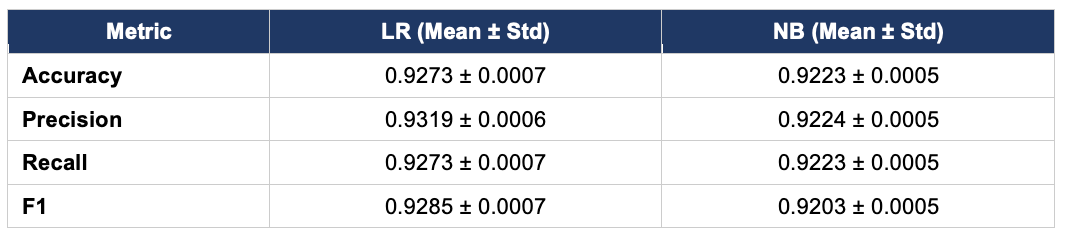

## 7. Interpretation and Substantive Takeaways
The model coefficients reveal several substantively important patterns about what students value in their educational experiences.
### 7.1 What Drives Positive Reviews
Three major factors comprise positive sentiment: Interpersonal care and warmth through words such as ‘helped,’ ‘cared,’ ‘willing’ and ‘cares’; The overall quality of the experience (as expressed by superlatives like ‘excellent,’ ‘amazing’ and ‘awesome’); and The ease of access to or ease in providing instruction (expressed in words like ‘easy,’ ‘clear’ and ‘helpful’). Beyond this, bigrams such as ‘wont regret,’ ‘best professors’ and ‘highly recommend’ capture recipient endorsements that would otherwise be missed by looking only at unigrams.
### 7.2 What Drives Negative Reviews
Negative feelings are associated with interpersonal interactions (for example: “rude,” “condescending,” “unprofessional”), lack of engagement (e.g., “boring,” “useless,” “wasted”), and avoidance signals (e.g., “avoid,” “stay away”). Notably, the word “rude” has a greater negative impact than “hard,” indicating that how instructors relate to their students is more important to someone’s satisfaction than how hard the course is. There are also many references to the unorganization/disorganization of the course, indicating that structural issues related to the delivery of the course contribute significantly to someone's dissatisfaction with the course.
### 7.3 What Readers Should and Should Not Conclude
There should be an understanding that text analysis can effectively pull out useful and interpretable themes from student reviews that provide more detailed information about the professors and courses than will be possible through the use of numerical ratings. The finding that the relational aspects (e.g., caring and rudeness) of faculty create a greater impact than the complaints about the difficulty of the course is a very strong and practical piece of information to use in developing faculty. However, there should not be any conclusions drawn regarding the ability of these models to capture the complexity of student sentiment. The analysis of student reviews uses a bag of words approach, which fails to account for negation, sarcasm, and meaning related to context. Additionally, due to the self-selection of the data from RateMyProfessors, this information reflects the opinions of students that have been motivated to write a review, and does not represent the entire population of students.

## 8. Limitations and Future Work
### 8.1 Limitations
There are three main limitations to discuss. The first is the imbalance in classes (the ratio of positives to negatives is 2.6:1), which gives the models more signal from training on positive reviews, so the models will not be able to learn the characteristics of negative classes as well as positive classes. The second issue is that bag-of-words models do not consider word order, so the most common problem with the models was that negations (for example, "not amazing") were not captured correctly. Finally, reviews on RateMyProfessors are self-selected and mostly from students with an extremely positive or negative opinion about the professor; thus, these results may not apply to course evaluations in institutions that invite all students to respond.
### 8.2 Future Work
There are some ways in which we can enhance our study. Investigating models aware of word order (for example, BERT and various transformer architecture based models) may only offer solutions to how to identify negation. Testing our model's generalizability using external datasets (such as institutional course evaluations) will provide evidence of the model's accuracy. Using topic modelling (for example, LDA) would allow us to break the positive/negative paradigm and create a more refined approach to making recommendations about pedagogy. Finally, sharing our results with staff from the Centre for Teaching and Learning may assist in the real-world impact of training professors.

## 9. References
ZephyrUtopia. (n.d.). RateMyProfessors Reviews Dataset. HuggingFace. https://huggingface.co/datasets/ZephyrUtopia/ratemyprofessors_reviews

### AI Acknowledgment
AI was used in writing some of the codes along with helping to rephrase the language in the report. The major contribution of GenAI tool was in code enhancement, language rephrasing for reports (improving sentence structure and grammar), image decoration (enhancing the designs of the images that resulted as an output of the codes) and writing of code outside the scope of SOSC 314 class at DKU.